In [1]:
!pip install pvlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 54.8 MB/s eta 0:00:00


In [2]:
import pvlib
import pandas as pd

In [3]:
import numpy as np

In [11]:
a3 = 33
a4 = np.tan(np.deg2rad(a3))
print(a4)

0.6494075931975106


In [21]:
porcentaje_final = []

In [28]:
p3 =[]

In [30]:
lat = -33.498
porcentaje_final = []
lat1 = 43.498
lon = -70.611
ah = 2.5 * np.sin(np.deg2rad(lat1))
distancia = 3
# Fecha y hora
dias = pd.date_range('2023-09-04', '2023-12-31',freq= 'D', tz = 'America/Santiago')
sombra = []
porcentaje =[]
pp = []
for dia in dias:
    # Horas del día
    tiempo = pd.date_range(
        start=dia,
        periods=24,
        freq='1h',
        tz='America/Santiago'
    )

    # Posición solar
    sol = pvlib.solarposition.get_solarposition(
        tiempo,
        lat,
        lon
    )
    # Guardar lista
    elevacion = sol['apparent_elevation'].tolist()
    sombra.append(elevacion)
# Ver resultado
for i in range(len(sombra)):
  sombra_dia = []
  for j in range(len(sombra[i])):
    if sombra[i][j] <= 5:
      sombrita = 0
    elif sombrita > 100:
      sombrita = 100
    else:
      L = ah / np.tan(np.deg2rad(sombra[i][j]))
      sombrita = max(0, min(100, ((L - distancia)/2.5)*100))
    sombra_dia.append(round(sombrita))
    pp.append(sombrita)

  porcentaje.append(sombra_dia)
for k in range(len(pp)):
  porcentaje_final.append(round(pp[k]))
for o in range(len(porcentaje)):
  p3.append(porcentaje[o])
a4 = len(p3)
print(p3)
print(a4)

[[0, 0, 0, 0, 0, 0, 0, 0, 100, 13, 0, 0, 0, 0, 0, 0, 0, 0, 0, 53, 100, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 100, 14, 0, 0, 0, 0, 0, 0, 0, 0, 0, 53, 100, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 100, 14, 0, 0, 0, 0, 0, 0, 0, 0, 0, 52, 100, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 100, 15, 0, 0, 0, 0, 0, 0, 0, 0, 0, 52, 100, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 100, 16, 0, 0, 0, 0, 0, 0, 0, 0, 0, 52, 100, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 100, 17, 0, 0, 0, 0, 0, 0, 0, 0, 0, 51, 100, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 100, 18, 0, 0, 0, 0, 0, 0, 0, 0, 0, 51, 100, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 100, 19, 0, 0, 0, 0, 0, 0, 0, 0, 0, 51, 100, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 100, 20, 0, 0, 0, 0, 0, 0, 0, 0, 0, 51, 100, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 100, 20, 0, 0, 0, 0, 0, 0, 0, 0, 0, 51, 100, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 100, 21, 0, 0, 0, 0, 0, 0, 0, 0, 0, 51, 100, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 100, 22, 0, 0, 0, 0, 0, 0, 0, 0, 0, 51, 100, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 100, 23, 0, 0,

In [18]:
import matplotlib.pyplot as plt


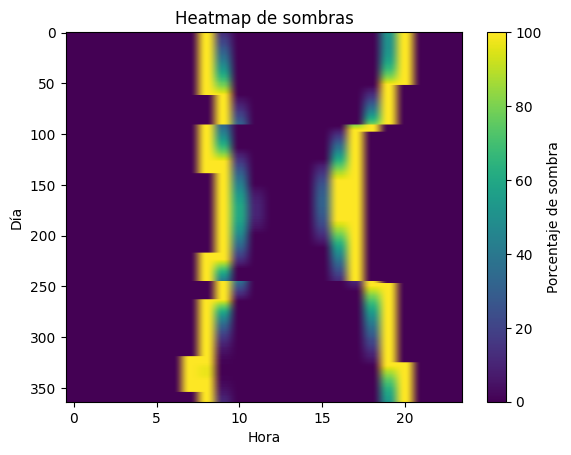

In [31]:
p3 = np.array(p3)

plt.imshow(p3, aspect='auto')
plt.colorbar(label='Porcentaje de sombra')

plt.xlabel("Hora")
plt.ylabel("Día")

plt.title("Heatmap de sombras")

plt.show()

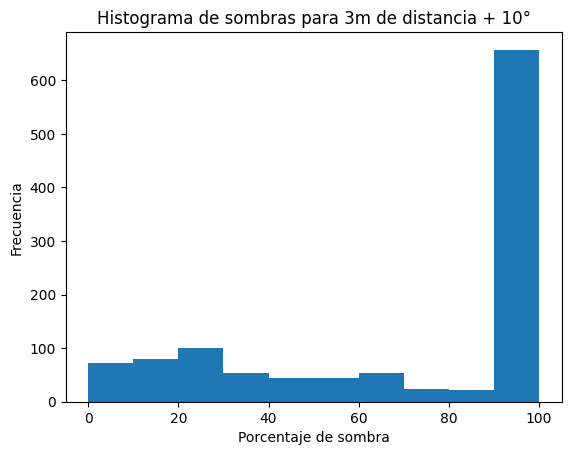

In [34]:
plt.hist(porcentaje_final, bins=np.arange(0,110,10))
plt.xlabel("Porcentaje de sombra")
plt.ylabel("Frecuencia")
plt.title("Histograma de sombras para 3m de distancia + 10°")
plt.show()